# STGNN for LA Buoy Network

In [24]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from datetime import datetime
# from tsl.data import SpatioTemporalDataset
# from tsl.datasets import Dataset

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.data import Batch
from torch_geometric.nn import GCNConv, GATv2Conv
from torch.optim.lr_scheduler import StepLR

In [25]:
dataLA = torch.load('../../experiments/data/pt/group/labn.pt')

X_train = dataLA['X_train']
y_train = dataLA['y_train']
X_test = dataLA['X_test']
y_test = dataLA['y_test']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

/var/folders/d0/7p4xxyy97qbb5_f74yjfh9vw0000gp/T/ipykernel_82324/2398716492.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dataLA = torch.load('../../experiments/data/p

(torch.Size([8760, 5, 16]),
 torch.Size([8760, 5, 1]),
 torch.Size([8760, 5, 16]),
 torch.Size([8760, 5, 1]))

In [26]:
def create_sequences_st(X, y, look_back, horizon):
    """
    Creates overlapping windows for multivariate time series data.

    Parameters:
        data (torch.Tensor): Input tensor of shape (a, c, b), where
                             a = number of time steps,
                             c = number of observations,
                             b = feature dimension.
        look_back (int): Number of past time steps to use as input.
        horizon (int): Number of future time steps to predict.

    Returns:
        X (torch.Tensor): Input tensor of shape (n, c, look_back, b), where
                          n = number of valid windows.
        y (torch.Tensor): Target tensor of shape (n, c, horizon, b).
    """
    # Get dimensions
    num_samples, num_observations, num_features = X.shape
    
    # Determine the number of valid windows
    n_windows = num_samples - look_back - horizon + 1
    if n_windows <= 0:
        raise ValueError("Not enough data to create windows with the given look_back and horizon sizes.")
    
    # Create input (X) and target (y) windows
    X_new = []
    y_new = []
    
    for i in range(n_windows):
        # Extract look-back window for all observations
        X_window = X[i:i + look_back]  # Shape: (look_back, c, b)
        
        # Extract prediction horizon for all observations
        # y_window = y[i + look_back:i + look_back + horizon]  # Shape: (horizon, c, b)
        y_window = y[i+look_back+horizon-1:i + look_back + horizon]  # Shape: (horizon, c, b)
        
        X_new.append(X_window)
        y_new.append(y_window)
    
    # Stack into tensors
    X_new = torch.stack(X_new)  # Shape: (n_windows, look_back, c, b)
    y_new = torch.stack(y_new)  # Shape: (n_windows, horizon, c, b)
    
    # Rearrange dimensions to match desired output shapes
    X_new = X_new.permute(0, 2, 1, 3)  # Shape: (n_windows, c, look_back, b)
    y_new = y_new.permute(0, 2, 1, 3)  # Shape: (n_windows, c, horizon, b)
    
    return X_new, y_new.squeeze().squeeze()


### Init data setup

In [27]:
X_train, y_train = create_sequences_st(X_train, y_train, look_back=24, horizon=8)
X_test, y_test = create_sequences_st(X_test, y_test, look_back=24, horizon=8)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([8729, 5, 24, 16]),
 torch.Size([8729, 5]),
 torch.Size([8729, 5, 24, 16]),
 torch.Size([8729, 5]))

## Temporal Neural Net
- MLP
- CNN

In [28]:
class TimeMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TimeMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        # self.fc2 = nn.Linear(hidden_size * 2, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        # x = torch.relu(self.fc2(x))
        # x = self.fc3(x)
        return x

class TimeCNN(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, fc_hidden, output_dim, kernel_size, stride):
        super(TimeCNN, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim1, kernel_size=kernel_size, stride=stride, padding=kernel_size//2)
        self.conv2 = nn.Conv1d(in_channels=hidden_dim1, out_channels=hidden_dim2, kernel_size=kernel_size, stride=stride, padding=kernel_size//2)
        self.conv3 = nn.Conv1d(in_channels=hidden_dim2, out_channels=output_dim, kernel_size=kernel_size, stride=stride, padding=kernel_size//2)
        
        # self.mean_pool = nn.AvgPool1d(kernel_size=kernel_size, stride=stride)
        self.mean_pool = nn.AdaptiveAvgPool1d(1)
        
        self.max_pool = nn.MaxPool1d(kernel_size=kernel_size, stride=stride)
        
        self.fc = nn.Linear(output_dim, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, 1)
        
        self.reset_parameters()

    def forward(self, x):
        t_len = x.shape[2]
        x = nn.ReLU()(self.conv1(x))
        x = self.mean_pool(x)
        
        x = nn.ReLU()(self.conv2(x))
        x = self.mean_pool(x)
        
        x = nn.ReLU()(self.conv3(x))
        x = self.mean_pool(x)
        
        x = x.squeeze(2)
        
        x = x.reshape(x.shape[0] // 5, 5, x.shape[1])
        # print("post conv reshape: ", x.shape)
        
        x = self.fc(x)
        x = nn.ReLU()(x)
        x = self.fc2(x)
        
        return x
    
    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, (nn.Conv1d, nn.Linear)):
                nn.init.kaiming_uniform_(module.weight, mode='fan_in', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

In [29]:
X_train_flat = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
y_train_flat = y_train.reshape(y_train.shape[0], y_train.shape[1])

X_test_flat = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
y_test_flat = y_test.reshape(y_test.shape[0], y_test.shape[1])

X_train_flat.shape, y_train_flat.shape, X_test_flat.shape, y_test_flat.shape

(torch.Size([8729, 5, 384]),
 torch.Size([8729, 5]),
 torch.Size([8729, 5, 384]),
 torch.Size([8729, 5]))

Temporal MLP

In [30]:
time_mlp = TimeMLP(input_size=X_train_flat.shape[2], hidden_size=240, output_size=1)

epochs = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(time_mlp.parameters(), lr=0.005)

time_mlp.train()

for epoch in range(epochs):
    time_mlp.train()

    optimizer.zero_grad()
    
    y_hat = time_mlp(X_train_flat)
    
    loss = criterion(y_hat.squeeze(), y_train_flat)
    
    loss.backward()
    optimizer.step()
    
    if epoch % (epochs // 10) == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')

eval_criterion = nn.L1Loss(reduction='none')

time_mlp.eval()
with torch.no_grad():
    y_pred = time_mlp(X_test_flat)
    
    loss = eval_criterion(y_pred.squeeze(), y_test_flat).mean(dim=0)
    print()
    print(f'Evaluation Loss: {loss}')

Epoch: 0, Loss: 10895.4736328125
Epoch: 10, Loss: 689605.375
Epoch: 20, Loss: 36706.48046875
Epoch: 30, Loss: 8843.859375
Epoch: 40, Loss: 1427.938720703125
Epoch: 50, Loss: 7138.0654296875
Epoch: 60, Loss: 4712.1611328125
Epoch: 70, Loss: 1425.43994140625
Epoch: 80, Loss: 299.76226806640625
Epoch: 90, Loss: 140.33827209472656

Evaluation Loss: tensor([4.5485, 2.0325, 2.4423, 3.5027, 4.4148])


Temporal CNN

In [31]:
X_train_cnn = X_train.permute(0,1,3,2)
# y_train_cnn = y_train.permute(0,1)
y_train_cnn = y_train

X_test_cnn = X_test.permute(0,1,3,2)
# y_test_cnn = y_test.permute(0,1,3,2)
y_test_cnn = y_test

In [32]:
# Shape: (num_samples * num_observations, num_features, look_back)
X_train_cnn_flat = X_train_cnn.reshape(X_train_cnn.shape[0] * X_train_cnn.shape[1], X_train_cnn.shape[2], X_train_cnn.shape[3])
# y_train_cnn_flat = y_train_cnn.reshape(y_train_cnn.shape[0] * y_train_cnn.shape[1], y_train_cnn.shape[2], y_train_cnn.shape[3])
y_train_cnn_flat = y_train_cnn

X_test_cnn_flat = X_test_cnn.reshape(X_test_cnn.shape[0] * X_test_cnn.shape[1], X_test_cnn.shape[2], X_test_cnn.shape[3])
# y_test_cnn_flat = y_test_cnn.reshape(y_test_cnn.shape[0] * y_test_cnn.shape[1], y_test_cnn.shape[2], y_test_cnn.shape[3])
y_test_cnn_flat = y_test_cnn

X_train_cnn_flat.shape, y_train_cnn_flat.shape, X_test_cnn_flat.shape, y_test_cnn_flat.shape

(torch.Size([43645, 16, 24]),
 torch.Size([8729, 5]),
 torch.Size([43645, 16, 24]),
 torch.Size([8729, 5]))

In [33]:
input_dim = X_train_cnn_flat.shape[1]
hidden_dim1 = 32
hidden_dim2 = 48
output_dim = 24
fc_hidden = 12

time_cnn = TimeCNN(input_dim, hidden_dim1, hidden_dim2, fc_hidden, output_dim, kernel_size=3, stride=1)

epochs = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(time_cnn.parameters(), lr=0.001)

time_cnn.train()

for epoch in range(epochs):
    time_cnn.train()

    optimizer.zero_grad()
    
    y_hat = time_cnn(X_train_cnn_flat)
    loss = criterion(y_hat.squeeze(), y_train_cnn_flat)
    
    loss.backward()
    optimizer.step()
    
    if epoch % (epochs // 10) == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')


eval_criterion = nn.L1Loss(reduction='none')

time_cnn.eval()
with torch.no_grad():
    y_pred = time_cnn(X_test_cnn_flat)
    
    loss = eval_criterion(y_pred.squeeze(), y_test_cnn_flat).mean(dim=0)
    print()
    print(f'Evaluation Loss: {loss}')

Epoch: 0, Loss: 2561607.25
Epoch: 10, Loss: 64392.94140625
Epoch: 20, Loss: 138.4038543701172
Epoch: 30, Loss: 385.6415710449219
Epoch: 40, Loss: 142.83522033691406
Epoch: 50, Loss: 15.877706527709961
Epoch: 60, Loss: 19.310291290283203
Epoch: 70, Loss: 9.090558052062988
Epoch: 80, Loss: 7.530219078063965
Epoch: 90, Loss: 7.442228317260742

Evaluation Loss: tensor([3.0355, 4.6593, 0.6893, 0.9936, 1.4647])


In [34]:
y_pred_save = y_pred.squeeze()
y_pred_save.shape, y_test_cnn_flat.shape

(torch.Size([8729, 5]), torch.Size([8729, 5]))

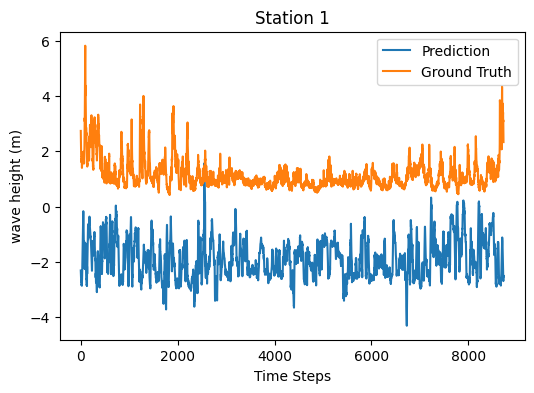

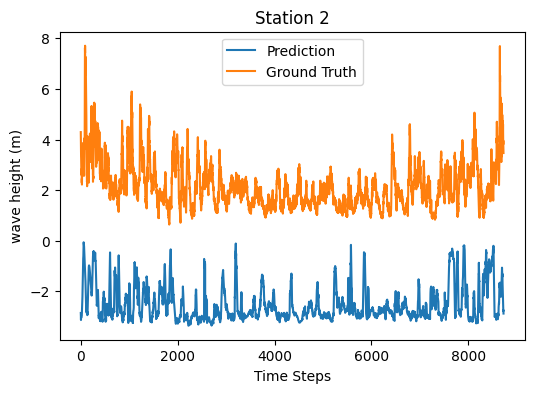

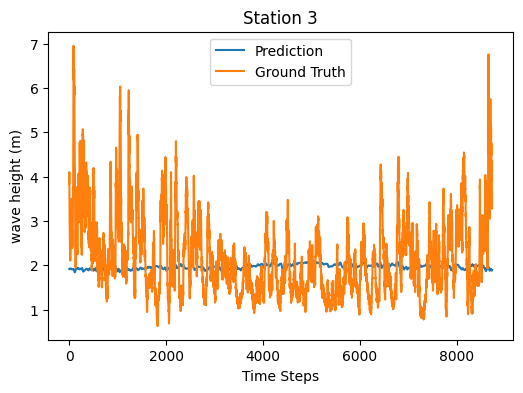

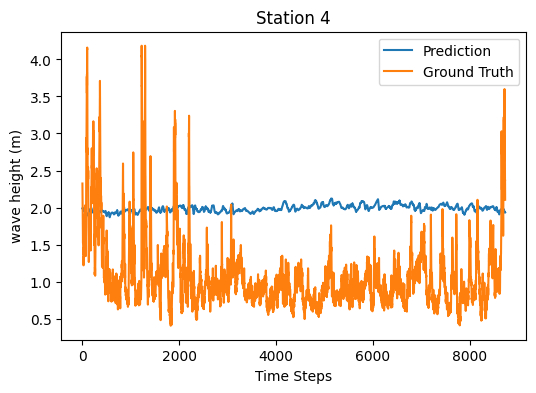

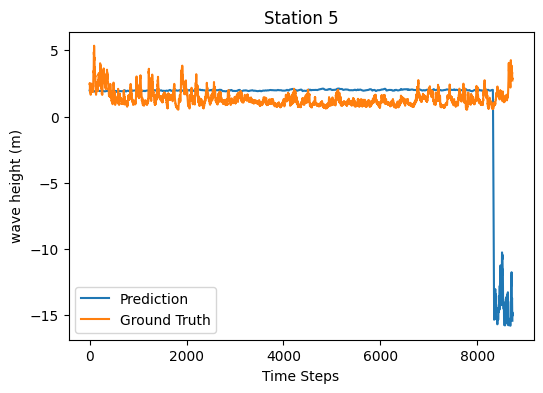

In [35]:
A = y_pred_save.shape[0]  # Number of time steps
B = y_pred_save.shape[1]    # Number of individual time-series gathering stations

pred_np = y_pred_save.numpy()
gt_np = y_test_cnn_flat.numpy()

# Create a time vector for the x-axis
time_steps = np.arange(A)

for station in range(B):
    plt.figure(figsize=(6, 4))
    plt.plot(time_steps, pred_np[:, station], label='Prediction')
    plt.plot(time_steps, gt_np[:, station], label='Ground Truth')
    plt.title(f'Station {station + 1}')
    plt.xlabel('Time Steps')
    plt.ylabel('wave height (m)')
    plt.legend()
    # plt.grid(True)
    plt.show()

## Geometric Neural Net

In [49]:
num_graphs = X_train.shape[0]
num_nodes = X_train.shape[1]
num_features = X_train.shape[2] * X_train.shape[3]

num_graphs, num_nodes, num_features

(8729, 5, 384)

creating graphs

In [50]:
edge_index = torch.combinations(torch.arange(num_nodes), r=2).t()
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

train_graphs = []
for i in range(num_graphs):
    node_features = X_train_flat[i]
    data = Data(x=node_features, edge_index=edge_index, y=y_train_flat[i])
    train_graphs.append(data)

test_graphs = []
for i in range(X_test.shape[0]):
    node_features = X_test_flat[i]
    data = Data(x=node_features, edge_index=edge_index, y=y_test_flat[i])
    test_graphs.append(data)
    
len(train_graphs), len(test_graphs)

(8729, 8729)

In [51]:
train_graphs[0], test_graphs[0]

(Data(x=[5, 384], edge_index=[2, 20], y=[5]),
 Data(x=[5, 384], edge_index=[2, 20], y=[5]))

In [52]:
train_batch = Batch.from_data_list(train_graphs)
test_batch = Batch.from_data_list(test_graphs)

In [53]:
# define GCN model
class SpaceGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SpaceGNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        # self.conv1 = GATv2Conv(input_dim, hidden_dim, heads=8, dropout=0.6)
        # self.conv2 = GATv2Conv(hidden_dim * 8, output_dim, heads=1, concat=False, dropout=0.4)
        
        self.linear = nn.Linear(output_dim, 1)
    
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        # x = nn.ReLU()(x)
        x = nn.LeakyReLU(negative_slope=0.2)(x)
        x = self.conv2(x, edge_index)
        # x = nn.ReLU()(x)
        # x = self.conv3(x, edge_index)
        # x = torch.relu(x)
        # x = self.linear(x)
        return x

Spatial Only Neural Net

In [54]:
space_gnn = SpaceGNN(input_dim=X_train_flat.shape[2], hidden_dim=80, output_dim=1)

epochs = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(space_gnn.parameters(), lr=0.01)
# scheduler = StepLR(optimizer, step_size=50, gamma=0.1)

space_gnn.train()

for epoch in range(epochs):
    space_gnn.train()

    optimizer.zero_grad()
    
    y_hat = space_gnn(train_batch.x, train_batch.edge_index)
    
    y_hat = y_hat.reshape(-1, y_train_flat.shape[1])
    target = train_batch.y.reshape(-1, y_train_flat.shape[1])
    
    loss = criterion(y_hat, target)
    
    loss.backward()
    optimizer.step()
    # scheduler.step()
    
    if epoch % (epochs // 10) == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')

eval_criterion = nn.L1Loss(reduction='none')

space_gnn.eval()
with torch.no_grad():
    y_hat = space_gnn(test_batch.x, test_batch.edge_index)
    y_hat = y_hat.reshape(-1, y_test_flat.shape[1])
    
    loss = eval_criterion(y_hat, y_test_flat).mean(dim=0)
    print()
    print(f'Loss: {loss}')

Epoch: 0, Loss: 15775426.0
Epoch: 10, Loss: 5051478.0
Epoch: 20, Loss: 4987239.5
Epoch: 30, Loss: 1408205.625
Epoch: 40, Loss: 201091.03125
Epoch: 50, Loss: 2455.981689453125
Epoch: 60, Loss: 51376.26953125
Epoch: 70, Loss: 24907.494140625
Epoch: 80, Loss: 742.3511962890625
Epoch: 90, Loss: 3988.74951171875

Loss: tensor([8.0778, 8.9481, 8.9403, 8.0040, 8.2399])


In [55]:
class TimeThenSpace(nn.Module):
    def __init__(self, input_dim, time_hidden, time_out, space_hidden, output_dim):
        super(TimeThenSpace, self).__init__()
        
        self.time_nn = nn.Sequential(
            nn.Linear(input_dim, time_hidden),
            nn.ReLU(),
            # nn.Linear(time_hidden * 2, time_hidden),
            # nn.ReLU(),
            nn.Linear(time_hidden, time_out)
        )
        # self.time_nn = nn.Linear(input_dim, time_out)
        
        self.space_nn = SpaceGNN(input_dim=time_out, hidden_dim=space_hidden, output_dim=output_dim)
        # self.space_nn = GCNConv(time_out, output_dim)
    
    def forward(self, x, edge_index):
        x = self.time_nn(x)
        x = self.space_nn(x, edge_index)
        return x

class SpaceThenTime(nn.Module):
    def __init__(self, input_dim, time_hidden, space_hidden, space_out, output_dim):
        super(SpaceThenTime, self).__init__()
        
        self.space_nn = SpaceGNN(input_dim=input_dim, hidden_dim=space_hidden, output_dim=space_out)
        
        self.time_nn = nn.Sequential(
            nn.Linear(space_out, time_hidden * 2),
            nn.ReLU(),
            nn.Linear(time_hidden * 2, time_hidden),
            nn.ReLU(),
            nn.Linear(time_hidden, 1)
        )
    
    def forward(self, x, edge_index):
        x = self.space_nn(x, edge_index)
        x = self.time_nn(x)
        return x

### Time then Space

In [56]:
time_then_space = TimeThenSpace(input_dim=X_train_flat.shape[2], time_hidden=240, time_out=60, space_hidden=32, output_dim=1)
space_then_time = SpaceThenTime(input_dim=X_train_flat.shape[2], time_hidden=48, space_hidden=80, space_out=64, output_dim=1)

epochs = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(time_then_space.parameters(), lr=0.001)

time_then_space.train()

for epoch in range(epochs):
    time_then_space.train()

    optimizer.zero_grad()
    
    y_hat = time_then_space(train_batch.x, train_batch.edge_index)
    y_hat = y_hat.reshape(-1, y_train_flat.shape[1])
    
    # loss = criterion(y_hat, y_train_flat)
    target = train_batch.y.reshape(-1, y_train_flat.shape[1])
    
    # loss = criterion(y_hat, y_train_flat)
    loss = criterion(y_hat, target)
    
    loss.backward()
    optimizer.step()
    
    if epoch % (epochs // 10) == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')
    
eval_criterion = nn.L1Loss(reduction='none')

time_then_space.eval()
with torch.no_grad():
    y_hat = time_then_space(test_batch.x, test_batch.edge_index)
    y_hat = y_hat.reshape(-1, y_test_flat.shape[1])
    
    loss = eval_criterion(y_hat, y_test_flat).mean(dim=0)
    print(f'Loss: {loss}')

Epoch: 0, Loss: 70013.8125
Epoch: 100, Loss: 39.55414581298828
Epoch: 200, Loss: 59.73863983154297
Epoch: 300, Loss: 24.948156356811523
Epoch: 400, Loss: 12.668561935424805
Epoch: 500, Loss: 7.706220626831055
Epoch: 600, Loss: 4.546454429626465
Epoch: 700, Loss: 3.9905595779418945
Epoch: 800, Loss: 3.465085029602051
Epoch: 900, Loss: 3.1768786907196045
Loss: tensor([1.1720, 1.9592, 1.9560, 1.1347, 1.2956])


Charting the STGNN preds against ground truth

In [60]:
loss.shape

torch.Size([5])

In [57]:
y_pred_save = y_hat.squeeze()
y_pred_save.shape, y_test_flat.shape

(torch.Size([8729, 5]), torch.Size([8729, 5]))

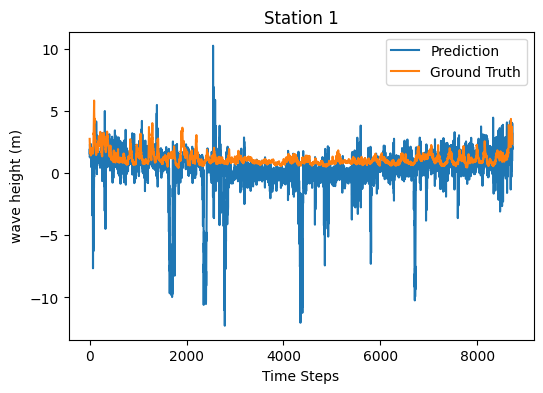

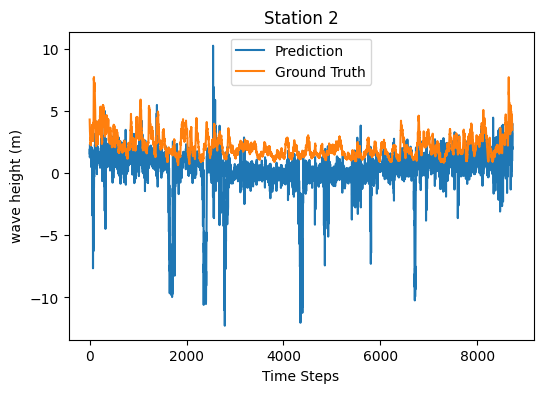

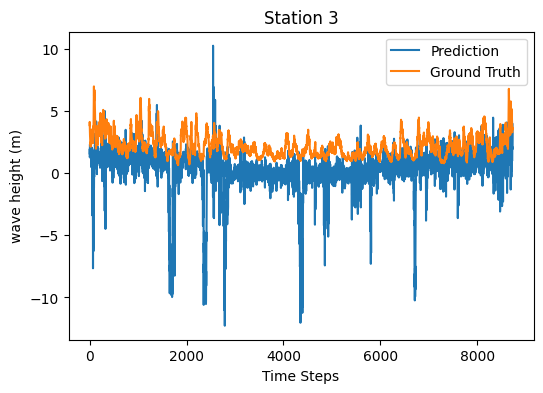

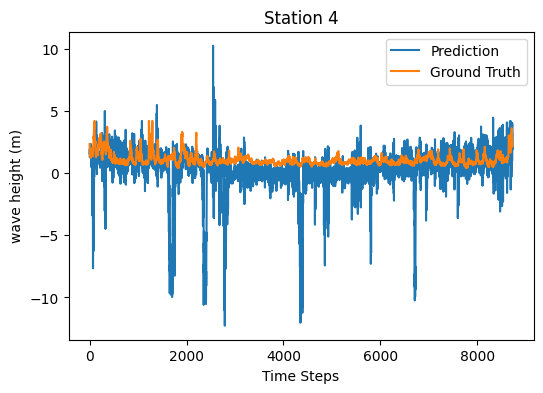

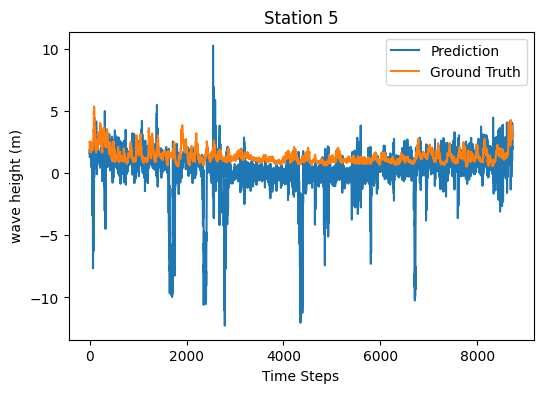

In [58]:
A = y_pred_save.shape[0]  # Number of time steps
B = y_pred_save.shape[1]    # Number of individual time-series gathering stations

pred_np = y_pred_save.numpy()
gt_np = y_test_flat.numpy()

# Create a time vector for the x-axis
time_steps = np.arange(A)

for station in range(B):
    plt.figure(figsize=(6, 4))
    plt.plot(time_steps, pred_np[:, station], label='Prediction')
    plt.plot(time_steps, gt_np[:, station], label='Ground Truth')
    plt.title(f'Station {station + 1}')
    plt.xlabel('Time Steps')
    plt.ylabel('wave height (m)')
    plt.legend()
    # plt.grid(True)
    plt.show()

### CNN with separate parameters

In [46]:
class TimeCNNGrouped(nn.Module):
    def __init__(self, sets, input_dim, hidden_dim1, hidden_dim2, fc_hidden, output_dim, kernel_size, stride):
        super(TimeCNNGrouped, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels=input_dim * sets, out_channels=hidden_dim1 * sets, kernel_size=kernel_size, stride=stride, padding=kernel_size//2)
        self.conv2 = nn.Conv1d(in_channels=hidden_dim1 * sets, out_channels=sets * output_dim, kernel_size=kernel_size, stride=stride, padding=kernel_size//2)
        
        # self.mean_pool = nn.AvgPool1d(kernel_size=kernel_size, stride=stride)
        self.mean_pool = nn.AdaptiveAvgPool1d(1)
        
        self.max_pool = nn.MaxPool1d(kernel_size=kernel_size, stride=stride)
        
        self.fc = nn.Linear(output_dim * sets, sets)
        # self.fc2 = nn.Linear(fc_hidden, 1)
        
        self.reset_parameters()

    def forward(self, x):
        t_len = x.shape[2]
        x = nn.ReLU()(self.conv1(x))
        x = self.mean_pool(x)
        
        x = nn.ReLU()(self.conv2(x))
        x = self.mean_pool(x)
        
        x = x.squeeze(2)
        
        # x = x.reshape(x.shape[0] // 5, 5, x.shape[1])
        # print("post conv reshape: ", x.shape)
        
        x = self.fc(x)
        # x = nn.ReLU()(x)
        # x = self.fc2(x)
        
        return x
    
    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, (nn.Conv1d, nn.Linear)):
                nn.init.kaiming_uniform_(module.weight, mode='fan_in', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

In [47]:
X_train_cnn_grouped = X_train_cnn.reshape(X_train_cnn.shape[0], X_train_cnn.shape[1] * X_train_cnn.shape[2], X_train_cnn.shape[3])
X_test_cnn_grouped = X_test_cnn.reshape(X_test_cnn.shape[0], X_test_cnn.shape[1] * X_test_cnn.shape[2], X_test_cnn.shape[3])

# shape = (N, num_nodes * num_features, seq_len)
X_train_cnn_grouped.shape, X_test_cnn_grouped.shape

(torch.Size([8729, 80, 24]), torch.Size([8729, 80, 24]))

In [48]:
input_dim = 16
hidden_dim1 = 32
hidden_dim2 = 48
output_dim = 24
fc_hidden = 12

cnn_grouped = TimeCNNGrouped(5, input_dim, hidden_dim1, hidden_dim2, fc_hidden, output_dim, kernel_size=3, stride=1)

epochs = 1000
criterion = nn.L1Loss(reduction='none')
optimizer = torch.optim.Adam(cnn_grouped.parameters(), lr=0.0005)

cnn_grouped.train()

for epoch in range(epochs):
    cnn_grouped.train()

    optimizer.zero_grad()
    
    y_hat = cnn_grouped(X_train_cnn_grouped)
    loss = criterion(y_hat.squeeze(), y_train).mean(dim=0)
    
    total_loss = loss.sum()
    total_loss.backward()
    optimizer.step()
    
    if epoch % (epochs // 10) == 0:
        print(f'Epoch: {epoch}, Loss: {loss}')


eval_criterion = nn.L1Loss(reduction='none')

cnn_grouped.eval()
with torch.no_grad():
    y_pred = cnn_grouped(X_train_cnn_grouped)
    
    loss = eval_criterion(y_pred.squeeze(), y_test).mean(dim=0)
    print()
    print(f'Evaluation Loss: {loss}')

Epoch: 0, Loss: tensor([ 420.4027,  902.5136,  399.7028, 1244.3346, 1749.5627],
       grad_fn=<MeanBackward1>)
Epoch: 100, Loss: tensor([10.1714, 23.3369, 11.3571,  4.7385, 17.3011], grad_fn=<MeanBackward1>)
Epoch: 200, Loss: tensor([  8.7912,  17.8861, 143.4266,   6.7647,  19.2311],
       grad_fn=<MeanBackward1>)
Epoch: 300, Loss: tensor([ 8.2220, 81.9599, 72.4112, 75.2150, 31.3308], grad_fn=<MeanBackward1>)


KeyboardInterrupt: 

### Separate convolutions with multiple models

In [55]:
X_train_cnn.shape

torch.Size([8729, 5, 16, 24])

In [63]:
X_train_cnn_separated = [X_train_cnn[:,i,:,:] for i in range(X_train_cnn.shape[1])]
X_test_cnn_separated = [X_test_cnn[:,i,:,:] for i in range(X_test_cnn.shape[1])]

y_train_cnn_separated = [y_train_cnn[:,i] for i in range(y_train_cnn.shape[1])]
y_test_cnn_separated = [y_test_cnn[:,i] for i in range(y_test_cnn.shape[1])]

X_train_cnn_separated[0].shape, X_test_cnn_separated[0].shape, y_train_cnn_separated[0].shape, y_test_cnn_separated[0].shape

(torch.Size([8729, 16, 24]),
 torch.Size([8729, 16, 24]),
 torch.Size([8729]),
 torch.Size([8729]))

In [74]:
class CNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, kernel_size, stride):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim, kernel_size=kernel_size, stride=stride, padding=kernel_size//2)
        self.conv2 = nn.Conv1d(in_channels=hidden_dim, out_channels=output_dim, kernel_size=kernel_size, stride=stride, padding=kernel_size//2)
        
        # self.mean_pool = nn.AvgPool1d(kernel_size=kernel_size, stride=stride)
        self.mean_pool = nn.AdaptiveAvgPool1d(1)
        
        self.max_pool = nn.MaxPool1d(kernel_size=kernel_size, stride=stride)
        
        # self.fc = nn.Linear(output_dim, fc_hidden)
        self.fc2 = nn.Linear(output_dim, 1)
        
        self.reset_parameters()

    def forward(self, x):
        t_len = x.shape[2]
        x = nn.ReLU()(self.conv1(x))
        x = self.mean_pool(x)
        
        x = nn.ReLU()(self.conv2(x))
        x = self.mean_pool(x)
        
        x = x.squeeze(2)
        
        # x = x.reshape(x.shape[0] // 5, 5, x.shape[1])
        # print("post conv reshape: ", x.shape)
        
        # x = self.fc(x)
        # x = nn.ReLU()(x)
        x = self.fc2(x)
        
        return x
    
    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, (nn.Conv1d, nn.Linear)):
                nn.init.kaiming_uniform_(module.weight, mode='fan_in', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

In [80]:
for station in range(5):
    X_train = X_train_cnn_separated[station]
    y_train = y_train_cnn_separated[station]
    X_test = X_test_cnn_separated[station]
    y_test = y_test_cnn_separated[station]
    
    input_dim = X_train.shape[1]
    hidden_dim = 32
    output_dim = 24
    fc_hidden = 12
    
    cnn = CNN(input_dim, hidden_dim, output_dim, kernel_size=3, stride=1)

    epochs = 100
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

    cnn.train()

    for epoch in range(epochs):
        cnn.train()

        optimizer.zero_grad()
        
        y_hat = cnn(X_train)
        loss = criterion(y_hat.squeeze(), y_train)
        
        loss.backward()
        optimizer.step()
        
        # if epoch % (epochs // 10) == 0:
        #     print(f'Epoch: {epoch}, Loss: {loss.item()}')


    eval_criterion = nn.L1Loss()

    cnn.eval()
    with torch.no_grad():
        y_pred = cnn(X_test)
        
        loss = eval_criterion(y_pred.squeeze(), y_test)
        print()
        print(f'Evaluation Loss for station {station}: {loss}')


Evaluation Loss for station 0: 3.246387004852295

Evaluation Loss for station 1: 2.444831371307373

Evaluation Loss for station 2: 1.0987839698791504

Evaluation Loss for station 3: 0.9889584183692932

Evaluation Loss for station 4: 3.7060229778289795
